# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Kalkstein 60°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 1314
Average Fx in the averaging interval [630:1944]: 5.859849218327887
Average Fz in the averaging interval [630:1944]: 2.758020790599434
Maximum Fz in the plotting interval [630:None]: 5.2667724609375 at timestep 1916
Time step where Fx drops below 1: 1944


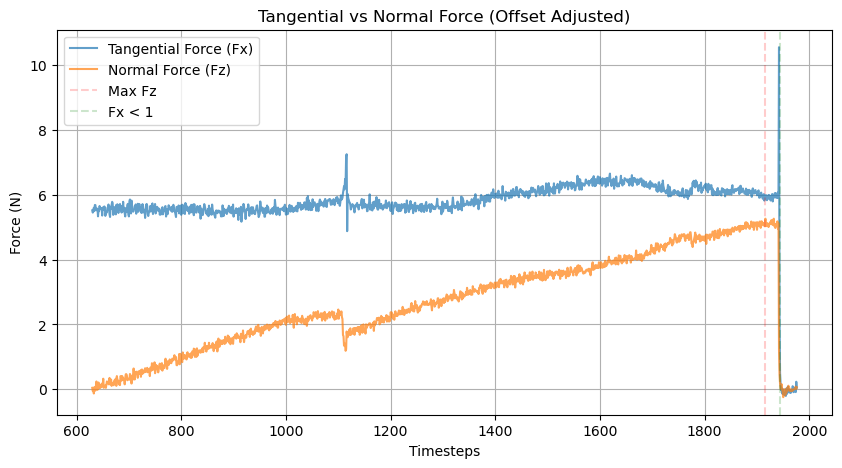

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241628.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=630, cut_2=None, avg_end=1944, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 715
Average Fx in the averaging interval [850:1565]: 5.34449918320129
Average Fz in the averaging interval [850:1565]: 1.209452339652535
Maximum Fz in the plotting interval [850:None]: 2.59017333984375 at timestep 1549
Time step where Fx drops below 1: 1565


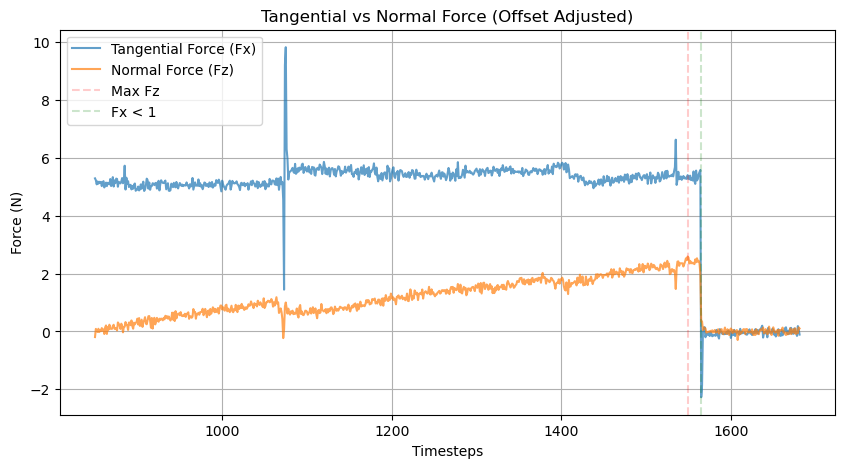

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241629.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=850, cut_2=None, avg_end=1565, offset_position='end', offset_length=15, fx_threshold=1)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 817
Average Fx in the averaging interval [570:1387]: 5.733004725178812
Average Fz in the averaging interval [570:1387]: 1.915344352831115
Maximum Fz in the plotting interval [570:None]: 3.9107625325520834 at timestep 1381
Time step where Fx drops below 1: 1387


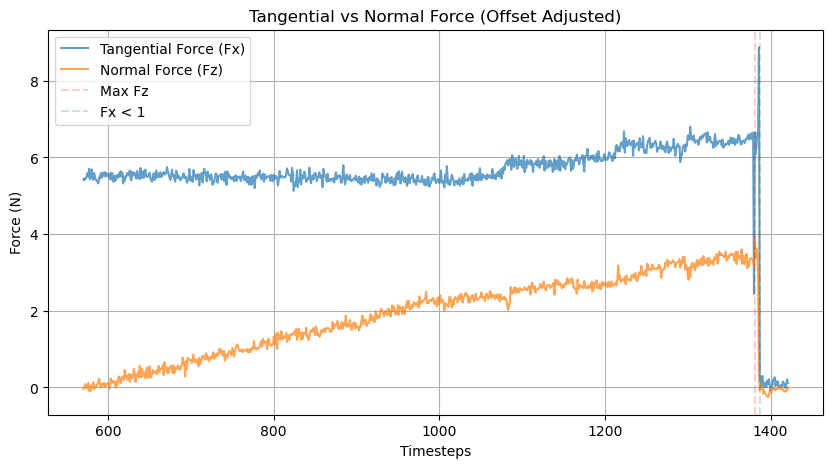

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241631.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=570, cut_2=None, avg_end=1387, offset_position='beginning', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 1388
Average Fx in the averaging interval [80:1468]: 6.163302710695294
Average Fz in the averaging interval [80:1468]: 1.985460162277295
Maximum Fz in the plotting interval [80:None]: 3.9134724934895835 at timestep 1450
Time step where Fx drops below 1: 1469


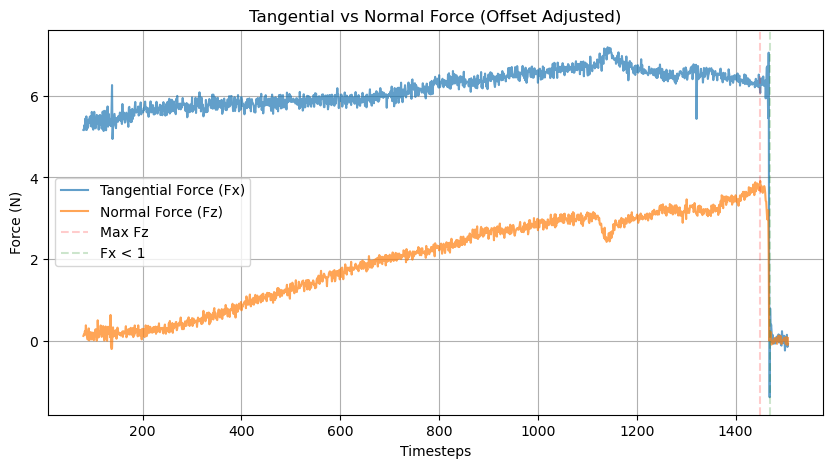

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241632.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=80, cut_2=None, avg_end=1468, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 508
Average Fx in the averaging interval [754:1262]: 5.618532902362152
Average Fz in the averaging interval [754:1262]: 1.0379341746252666
Maximum Fz in the plotting interval [754:None]: 1.8120157877604166 at timestep 1245
Time step where Fx drops below 1: 1262


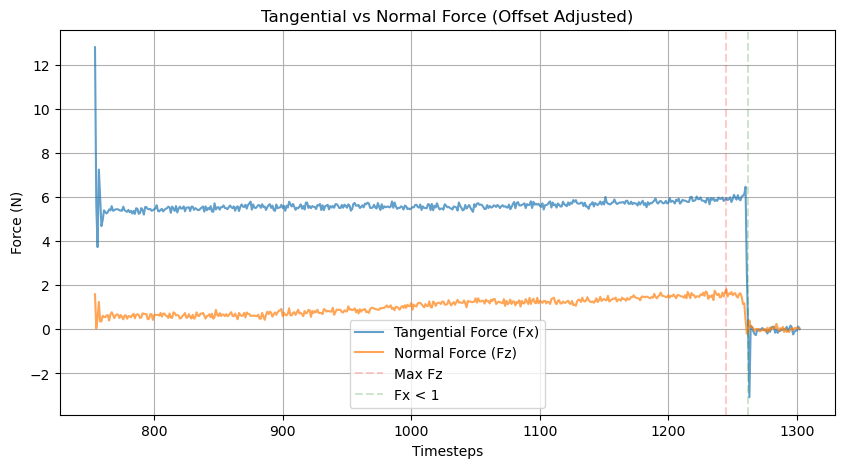

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241633.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=754, cut_2=None, avg_end=1262, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 934
Average Fx in the averaging interval [1350:2284]: 5.959697661716372
Average Fz in the averaging interval [1350:2284]: 2.4439366996160667
Maximum Fz in the plotting interval [1350:None]: 3.83858642578125 at timestep 2275
Time step where Fx drops below 1: 2284


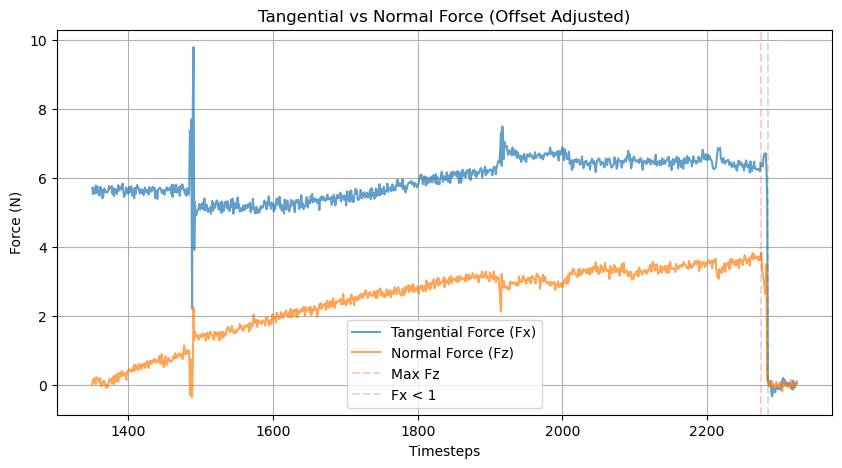

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241634.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1350, cut_2=None, avg_end=2284, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 719
Average Fx in the averaging interval [1060:1779]: 5.739842977554753
Average Fz in the averaging interval [1060:1779]: 2.1534540465544594
Maximum Fz in the plotting interval [1060:None]: 3.84512939453125 at timestep 1745
Time step where Fx drops below 1: 1779


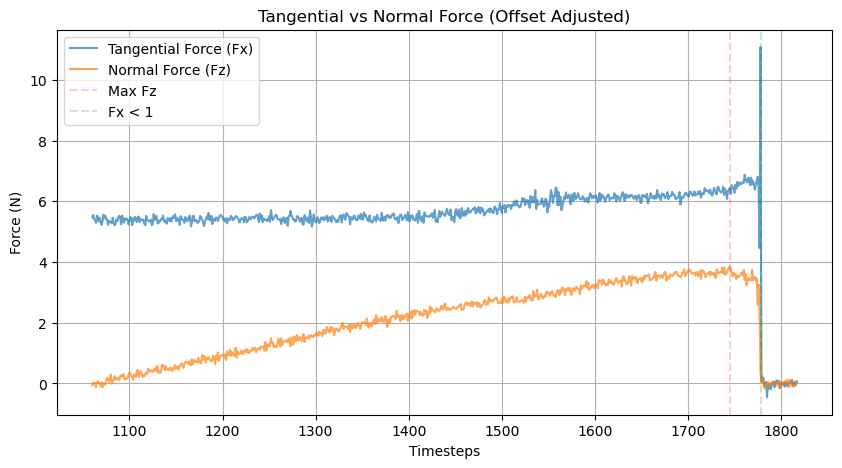

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241636.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=1060, cut_2=None, avg_end=1779, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 1326
Average Fx in the averaging interval [390:1716]: 5.9282114507206245
Average Fz in the averaging interval [390:1716]: 2.3889887606935805
Maximum Fz in the plotting interval [390:None]: 4.4162841796875 at timestep 1708
Time step where Fx drops below 1: 1716


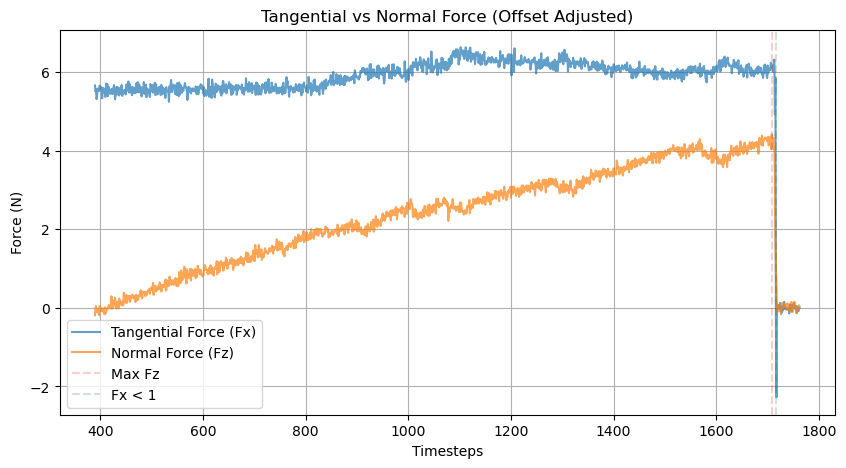

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241637.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=390, cut_2=None, avg_end=1716, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1463
Average Fx in the averaging interval [750:2213]: 5.893250011979488
Average Fz in the averaging interval [750:2213]: 2.6085346339259012
Maximum Fz in the plotting interval [750:None]: 4.900830078125 at timestep 2200
Time step where Fx drops below 1: 2213


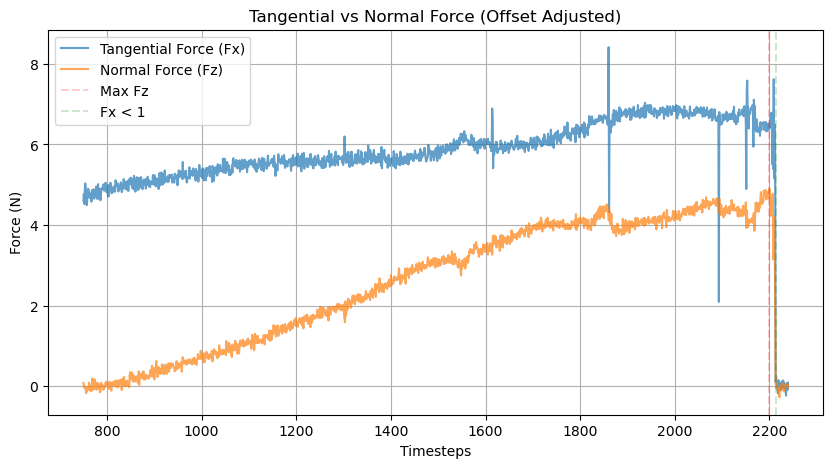

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241640.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=750, cut_2=None, avg_end=2213, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 411
Average Fx in the averaging interval [710:1121]: 5.344829463494666
Average Fz in the averaging interval [710:1121]: 1.199738276497871
Maximum Fz in the plotting interval [710:None]: 2.657881673177083 at timestep 1103
Time step where Fx drops below 1: 1121


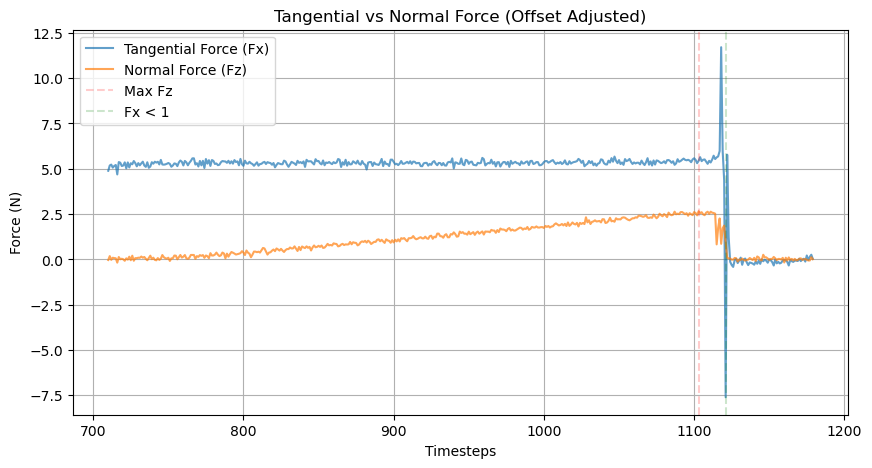

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241641.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=710, cut_2=None, avg_end=1121, offset_position='end', offset_length=15)

<font size="6">Test 11a: (worked)</font>

Length from cut_1 to avg_end: 995
Average Fx in the averaging interval [250:1245]: 5.801184881392436
Average Fz in the averaging interval [250:1245]: 1.1175831345856888
Maximum Fz in the plotting interval [250:1268]: 2.8835774739583333 at timestep 1202
Time step where Fx drops below 1: 1247


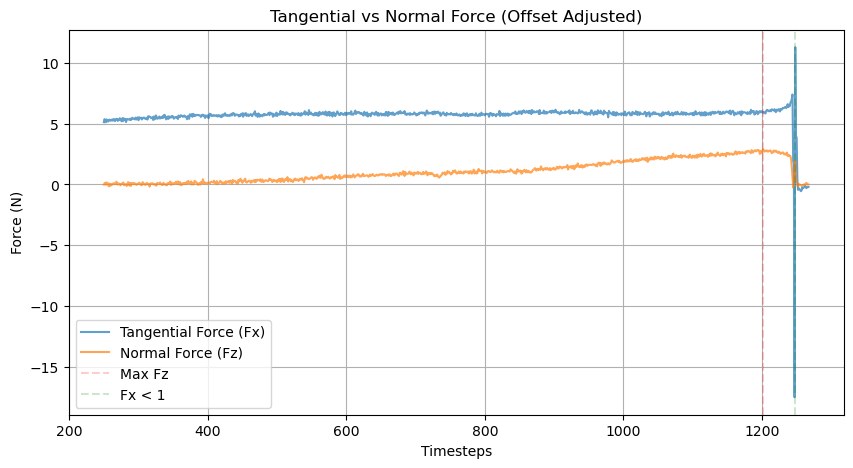

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241642.csv"
df = pd.read_csv(data)
test_11a, end_11a = plot_forces(df, cut_1=250, cut_2=1268, avg_end=1245, offset_position='end', offset_length=15)

<font size="6">Test 11b: (worked)</font>

Length from cut_1 to avg_end: 985
Average Fx in the averaging interval [1480:2465]: 5.409831008330214
Average Fz in the averaging interval [1480:2465]: 2.0613319874616645
Maximum Fz in the plotting interval [1480:None]: 4.239656575520834 at timestep 2460
Time step where Fx drops below 1: 2465


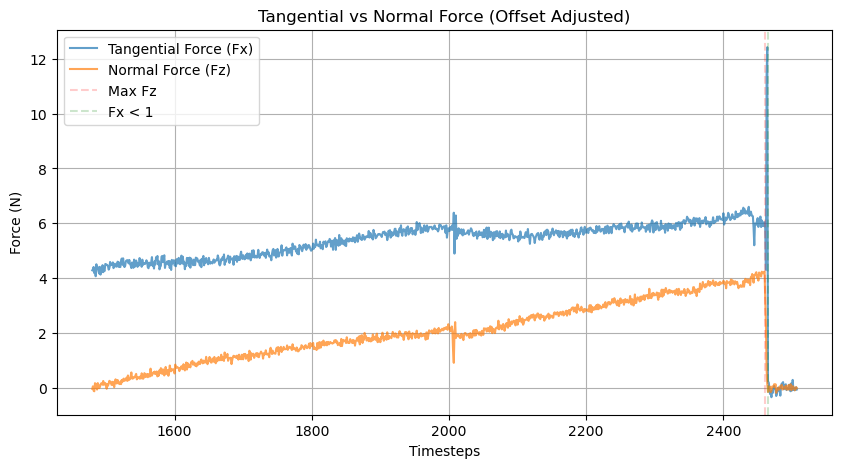

In [14]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_60_5N//log_202405241642.csv"
df = pd.read_csv(data)
test_11b, end_11b = plot_forces(df, cut_1=1480, cut_2=None, avg_end=2465, offset_position='end', offset_length=15)

In [15]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [19]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//60//Kalkstein_60_stats.csv", index=False)

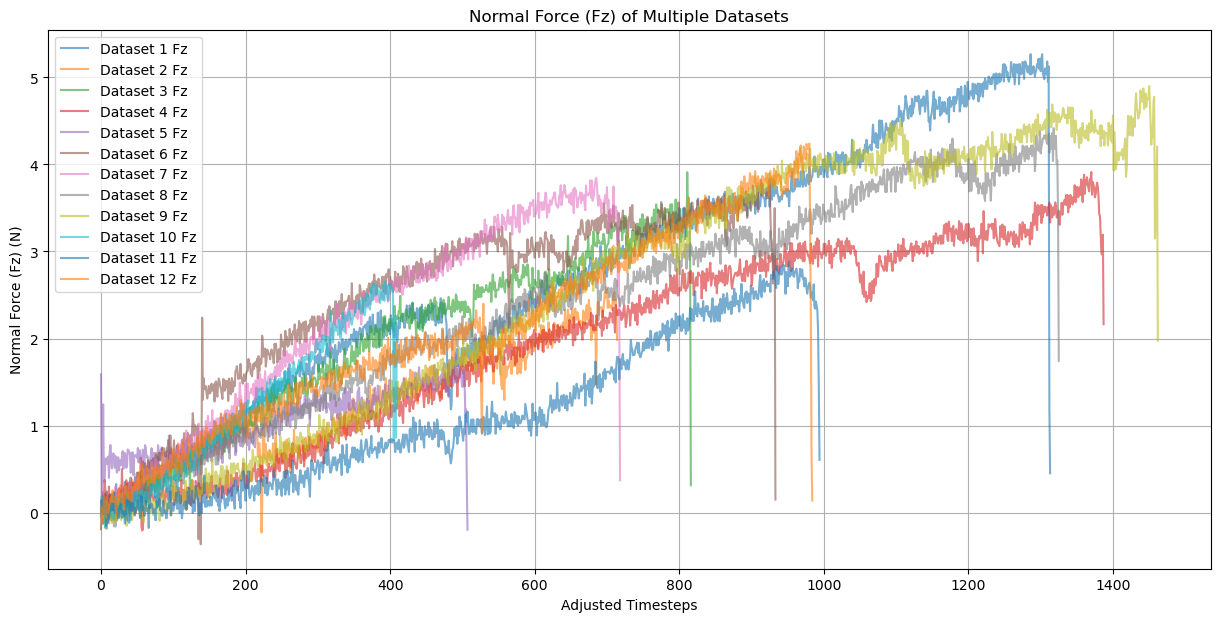

Average of maximum Fz forces: 3.6895952012803814
Standard deviation of maximum Fz forces: 0.9737717899564031
Average of average Fz forces: 1.9066482799434066
Standard deviation of average Fz forces: 0.5911168661880319
Average of average Fx forces: 5.733003016246166
Standard deviation of average Fx forces: 0.2483741669453795


In [20]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10, test_11a, test_11b]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10, end_11a, end_11b]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [21]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//60//Kalkstein_60"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)